<a href="https://colab.research.google.com/github/ldaniel-hm/eml_approximate/blob/main/Dos_formas_de_discretizar_espacios_continuos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dos Formas de Discretizar Espacios Continuos**

En este notebook se muestra como adaptar los espacios de estados continuos para que se puedan aplicar los métodos tabulares de aprendizaje por refuerzo en el entorno Gymnasium


## Preparamos el entorno que se usará en el notebook


In [1]:
#@title Importamos las librerias necesarias
import random
import gymnasium as gym
from gymnasium import ObservationWrapper
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from environments.mountain_car import make_mountain_car_env
from utils.discretizar import StateAggregationEnv
from algorithms.dqn_agent import DQNAgent
from utils.plotting import plot_curve
from policies.epsilon_greedy import compute_q

In [2]:
#@title Cargamos el entorno
NUM_EPISODES = 500
SEED = 100
BIN_SIZE = 20

env = make_mountain_car_env(seed=SEED, render_mode="rgb_array")

print("Estados:", env.observation_space)
print("Acciones:", env.action_space)


Estados: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Acciones: Discrete(3)


In [3]:
def summarize_results(name, rewards):
    print(f"\n=== {name} ===")
    print(f"Máximo: {np.max(rewards):.2f}")
    print(f"Media últimos 100: {np.mean(rewards[-100:]):.2f}")
    print(f"Último episodio: {rewards[-1]:.2f}")

## Este es el entorno

In [4]:
env.render()

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

### **Las acciones del entorno**

La acciones disponibles son:
- 0: Acelerar a la izquierda.
- 1: No acelerar
- 2: Acelerar a la derecha

### **Los estados del entorno**

Las observaciones es un ndarray con dimensión (2,) donde los elementos se corresponde a los siguientes valores:

| Número | Observación                          | Mínimo | Máximo | Unidad        |
|--------|--------------------------------------|--------|--------|---------------|
| 0      | Posición del coche en el eje x      | -1.2   | 0.6    | posición (m)  |
| 1      | Velocidad del coche                 | -0.07  | 0.07   | velocidad (v) |


# Discretización usando Agregación

Podemos pasar de un espacio continuo de observaciones $[-1.2, 0.6]\times [-0.07, 0.07]$ a un espacio discreto. Para ello, discretizamos cada dimensión con una partición de intervalos. A esto se le llama **agregación.**


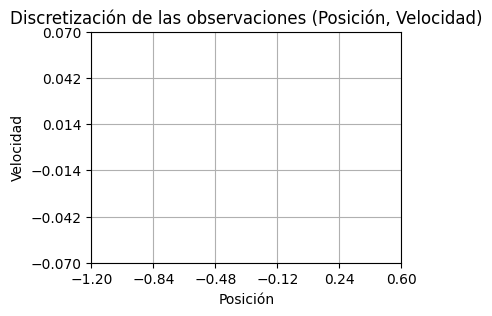

In [5]:
#@title Por ejemplo, podemos discretizar el espacio en solo 25 observaciones
# Definir los rangos para la posición y la velocidad
x_min, x_max = -1.2, 0.6    # Rango para la posición (eje X)
y_min, y_max = -0.07, 0.07  # Rango para la velocidad (eje Y)

# Crear la figura y el eje
fig, ax = plt.subplots(figsize=(4, 3))

# Establecer los límites de los ejes
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Dividir el eje X en 5 partes (6 ticks) y el eje Y en 5 partes (6 ticks)
x_ticks = np.linspace(x_min, x_max, 6)
y_ticks = np.linspace(y_min, y_max, 6)

# Asignar los ticks a los ejes
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)

# Activar la grilla para mostrar las divisiones
ax.grid(True)

# Etiquetas y título para la gráfica
ax.set_xlabel("Posición")
ax.set_ylabel("Velocidad")
ax.set_title("Discretización de las observaciones (Posición, Velocidad)")

# Mostrar la gráfica
plt.show()

### Creamos *una* agregación de estados

- Necesitamos hacer un Wrapper sobre el espacio de observaciones
- Vamos a discritizar para trabajar con 400 estados. La posición se discretiza en 20 valores y la velocidad en otros 20 valores

In [6]:
#@title Dividimos cada dimensión en 20 intervalos. Al nuevo espacio lo llamaremos *saenv*

bins = np.array([BIN_SIZE, BIN_SIZE*2])
low = env.observation_space.low
high = env.observation_space.high
saenv = StateAggregationEnv(env, bins=bins, low=low, high=high)
saenv.buckets

[array([-1.2       , -1.1       , -1.        , -0.90000004, -0.8000001 ,
        -0.70000005, -0.6       , -0.50000006, -0.40000004, -0.3       ,
        -0.20000005, -0.10000002,  0.        ,  0.10000002,  0.19999993,
         0.29999995,  0.39999998,  0.5       ,  0.6       ], dtype=float32),
 array([-0.07      , -0.06631579, -0.06263158, -0.05894737, -0.05526316,
        -0.05157895, -0.04789474, -0.04421053, -0.04052632, -0.0368421 ,
        -0.03315789, -0.02947368, -0.02578947, -0.02210526, -0.01842105,
        -0.01473684, -0.01105263, -0.00736842, -0.00368421,  0.        ,
         0.00368422,  0.00736842,  0.01105263,  0.01473685,  0.01842105,
         0.02210526,  0.02578948,  0.02947368,  0.03315789,  0.03684211,
         0.04052632,  0.04421053,  0.04789474,  0.05157895,  0.05526315,
         0.05894738,  0.06263158,  0.06631579,  0.07      ], dtype=float32)]

In [7]:
#@title Comparamos el entorno original con el entorno con estados agregados

print(f"El espacio de observaciones original es: {env.observation_space}, \n\
Un estado para este espacio es: {env.observation_space.sample()}")
print(f"El espacio de estados modificado es: {saenv.observation_space}, \n\
Un estado para este espacio es: {saenv.observation_space.sample()}")

El espacio de observaciones original es: Box([-1.2  -0.07], [0.6  0.07], (2,), float32), 
Un estado para este espacio es: [ 0.54502004 -0.02970464]
El espacio de estados modificado es: MultiDiscrete([20 40]), 
Un estado para este espacio es: [8 2]


# Ejecucion

In [8]:
#@title Inicializar Deep Q-Learning

state_dim = 2  # MountainCar tiene posición y velocidad
n_actions = saenv.action_space.n

dqn_agent = DQNAgent(
    saenv,
    state_dim=state_dim,
    n_actions=n_actions,
    lr=1e-3,
    gamma=0.99,
    epsilon=0.3,
    epsilon_min=0.05,
    epsilon_decay=0.995,
    batch_size=64,
    target_update=50
)

In [9]:
#@title Aprendizaje Deep Q-Learning

dqn_rewards, dqn_steps = dqn_agent.train(episodes=NUM_EPISODES)

DQN Training: 100%|██████████| 500/500 [02:19<00:00,  3.58it/s]


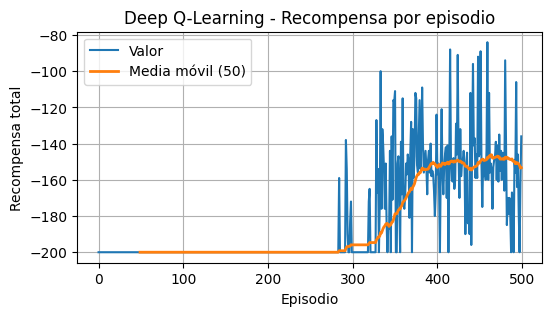

In [10]:
#@title Recompensa por episodio

plot_curve(
    dqn_rewards,
    title="Deep Q-Learning - Recompensa por episodio",
    ylabel="Recompensa total",
    moving_avg_window=50
)


In [11]:
summarize_results("Deep Q-Learning", dqn_rewards)


=== Deep Q-Learning ===
Máximo: -84.00
Media últimos 100: -152.11
Último episodio: -136.00


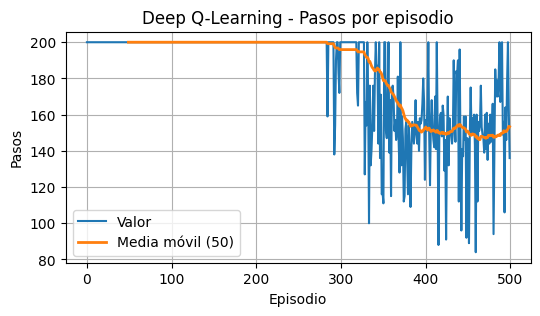

In [12]:
plot_curve(
    dqn_steps,
    title="Deep Q-Learning - Pasos por episodio",
    ylabel="Pasos",
    moving_avg_window=50
)

In [13]:
#@title Estadísticas del modelo aprendido

import torch

print("Norma de los pesos Q-network:",
      torch.norm(dqn_agent.q_net.net[0].weight).item())

print("Epsilon final:", dqn_agent.epsilon)

Norma de los pesos Q-network: 5.995355606079102
Epsilon final: 0.05


In [14]:
#@title Política greedy obtenida

state, _ = saenv.reset()
done = False

actions = []

while not done:

    state_tensor = np.array(state, dtype=np.float32)

    action = dqn_agent.select_action(state_tensor)
    actions.append(str(action))

    next_state, _, terminated, truncated, _ = saenv.step(action)
    state = next_state

    done = terminated or truncated

print("Secuencia de acciones greedy:", ", ".join(actions))

Secuencia de acciones greedy: 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2
